# Analytical Study of the Tree Level Potential

In [1]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.lines as mlines
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator
from matplotlib.colors import TwoSlopeNorm
import matplotlib.patheffects as pe

from cosmoTransitions import pathDeformation, transitionFinder
from cosmoTransitions import pathDeformation

from scipy.optimize import minimize, brentq
from scipy.optimize import minimize_scalar
from scipy.optimize import shgo

import time

from xSM_Model import xSM

In [3]:
def physical_to_lagrangian(m1, m2, theta, v, u, lHS, lS):
    """
    Convert physical parameters to xSM Lagrangian parameters.

    Inputs
    ------
    m1, m2  : scalar mass eigenvalues (GeV), m1 < m2 convention
    theta   : mixing angle (rad)
    v, u    : Higgs and singlet vevs (GeV)
    lHS     : quartic portal lambda_HS
    lS      : singlet quartic lambda_S

    Outputs
    -------
    dict with keys: lH, muHS, mu3, muH2, muS2
    (lHS and lS are inputs, returned unchanged for completeness)
    """
    ct = np.cos(theta)
    st = np.sin(theta)
    
    Mhh = m1**2 * ct**2 + m2**2 * st**2
    Mss = m1**2 * st**2 + m2**2 * ct**2
    Mhs = (m1**2 - m2**2) * ct * st
    
    lH   = Mhh / (2.0 * v**2)

    muHS = Mhs / v  -  lHS * u

    # Relations don't hold if u=0
    if abs(u) > 1e-6:
        mu3 = (2.0*lS*u**2  -  Mss  -  muHS*v**2/(2.0*u)) / u
    else:
        mu3 = 0.0   

    # Mass parameters from tadpole conditions
    muH2 = lH*v**2  +  0.5*lHS*u**2  +  muHS*u
    if abs(u) > 1e-6:
        muS2 = 0.5*lHS*v**2  +  muHS*v**2/(2.0*u)  +  lS*u**2  -  mu3*u
    else:
        muS2 = 0.0

    return dict(lH=lH, lHS=lHS, muHS=muHS, lS=lS, mu3=mu3, muH2=muH2, muS2=muS2)

In [5]:
def check_stability(params, v0=246.22, u0=0.0, bounds=None, n=200, atol=0.5, verbose=True):
    """
    Checks vacuum (meta)stability of the xSM potential for a given set of
    Lagrangian parameters by comparing the electroweak minimum (v, u) found
    via the model's own OS solution against the global minimum found by
    SHGO global optimization.

    Parameters
    ----------
    params : dict
        Dictionary containing the Lagrangian parameters, must include at
        least the keys 'lH', 'lHS', 'muHS', 'lS', 'mu3'.
    v0, u0 : float
        Initial guesses for the Higgs and singlet vevs, passed to the xSM
        model constructor.
    bounds : list of tuples, optional
        Bounds for the SHGO search over (v, u). Defaults to
        [(0, 350), (-200, 1000)].
    n : int
        Sampling density for SHGO.
    atol : float
        Absolute tolerance (GeV) used to compare the EW vacuum to the
        global minimum found by SHGO.
    verbose : bool
        If True, prints diagnostic information.

    Returns
    -------
    dict
        {
            'v_ew': float,          # EW vacuum Higgs vev (from model.v_os)
            'u_ew': float,          # EW vacuum singlet vev (from model.u_os)
            'v_global': float,      # global minimum Higgs vev (from SHGO)
            'u_global': float,      # global minimum singlet vev (from SHGO)
            'is_metastable': bool,  # True if EW vacuum != global minimum
            'execution_time': float # SHGO runtime in seconds
        }
    """
    if bounds is None:
        bounds = [(0, 350), (-200, 1000)]

    # Build the model with the given Lagrangian parameters
    model = xSM(**{k: params[k] for k in ['lH', 'lHS', 'muHS', 'lS', 'mu3']},
                v=v0, u=u0)

    v_ew = model.v_os
    u_ew = model.u_os

    # Run SHGO global optimization
    start_time = time.perf_counter()
    res = shgo(
        lambda x: model.Vtot(np.array([[x[0], x[1]]]), 0.0).item(),
        bounds=bounds,
        n=n
    )
    end_time = time.perf_counter()
    execution_time = end_time - start_time

    v_global, u_global = res.x

    is_metastable = not (np.isclose(v_global, v_ew, atol=atol) and
                          np.isclose(u_global, u_ew, atol=atol))

    if verbose:
        print(f"EW minimum:          v = {v_ew:.3f}, u = {u_ew:.3f}")
        print(f"Global minimum found: v = {v_global:.3f}, u = {u_global:.3f}")
        print(f"SHGO optimization finished in {execution_time:.6f} seconds.")
        if is_metastable:
            print("Potential is Metastable")
        else:
            print("Saul Good Man")

    return {
        'v_ew': v_ew,
        'u_ew': u_ew,
        'v_global': v_global,
        'u_global': u_global,
        'is_metastable': is_metastable,
        'execution_time': execution_time
    }

## Stable Potential

In [345]:
v0=246.22
u0=200
params = physical_to_lagrangian(
    m1    = 125.20,   # GeV  
    m2    = 60.0,    # GeV 
    theta = 0.001,      # rad  
    v     = v0,   # GeV
    u     = u0,     # GeV 
    lHS   = 0.05,     #     
    lS    = 0.05,      #     
)
print(params)

model = xSM(**{k: params[k] for k in ['lH','lHS','muHS','lS','mu3']},v=v0, u=u0)

{'lH': 0.12928009827958678, 'lHS': 0.05, 'muHS': -9.950958362643266, 'lS': 0.05, 'mu3': 9.54081174523609, 'muH2': 6847.3222899533575, 'muS2': 99.27043686958905}


In [271]:
result = check_stability(params, v0=v0, u0=u0)

EW minimum:          v = 246.220, u = 200.000
Global minimum found: v = 246.220, u = 200.000
SHGO optimization finished in 0.116930 seconds.
Saul Good Man


In [347]:
lH   = params["lH"]
lHS  = params["lHS"]
muHS = params["muHS"]
muH2  = params["muH2"]

s_min = np.linspace(-200, 400, 1000)
radicand = -s_min**2 * lHS + 2*muH2 - 2*s_min*muHS

h_plus  = np.full_like(s_min, np.nan)
h_minus = np.full_like(s_min, np.nan)

valid = radicand >= 0
h_plus[valid]  =  np.sqrt(radicand[valid]) / (np.sqrt(2) * np.sqrt(lH))
h_minus[valid] = -np.sqrt(radicand[valid]) / (np.sqrt(2) * np.sqrt(lH))

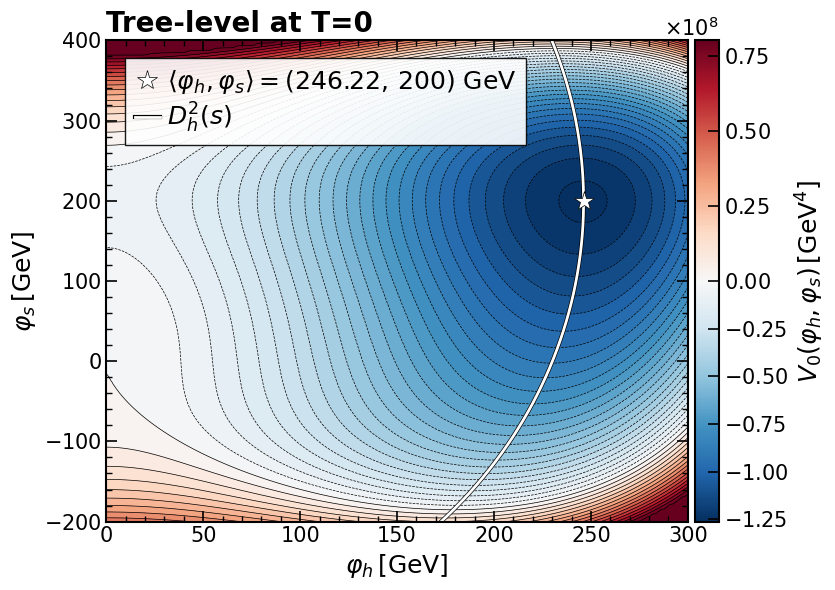

In [349]:
h_vals = np.linspace(0, 300, 200)
s_vals = np.linspace(-200, 400, 200)
H, S   = np.meshgrid(h_vals, s_vals)
X_grid = np.column_stack([H.ravel(), S.ravel()])
V_grid = model.V0(X_grid).reshape(H.shape)
V_plot = np.clip(V_grid, np.percentile(V_grid, 0), np.percentile(V_grid, 99))
V_shifted = V_plot - model.V0(np.array([[0.0, 0.0]]))

norm = TwoSlopeNorm(vcenter=0, vmin=V_shifted.min(), vmax=V_shifted.max())
sm   = ScalarMappable(cmap='RdBu_r', norm=norm)

fig, ax = plt.subplots(figsize=(8.5, 6))

cp = ax.contourf(H, S, V_shifted, levels=50, cmap='RdBu_r', norm=norm)
ax.contour(H, S, V_shifted, levels=50, colors='k', linewidths=0.5, alpha=1)
ax.plot(v0, u0, 'w*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,label=rf'$\langle\varphi_h, \varphi_s\rangle = ({v0:.2f},\,{u0:.0f})$ GeV')
ax.plot(h_plus, s_min, label=r'$D_h^2(s)$', color='w', lw=2, ls='-', path_effects=[pe.Stroke(linewidth=3, foreground='black'), pe.Normal()])

ax.set_xlabel(r'$\varphi_h \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\varphi_s \, [\mathrm{GeV}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1,   labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$V_{0}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
cbar.ax.yaxis.get_offset_text().set_fontsize(15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(-2,3))
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

ax.legend(fontsize=18, frameon=True, fancybox=False, loc = "upper left", bbox_to_anchor=(0.01, 0.99),ncol = 1, edgecolor="black", framealpha=0.9, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Tree-level at T=0", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("Figures\TL_Contour.pdf", format="pdf", bbox_inches="tight")
plt.show()

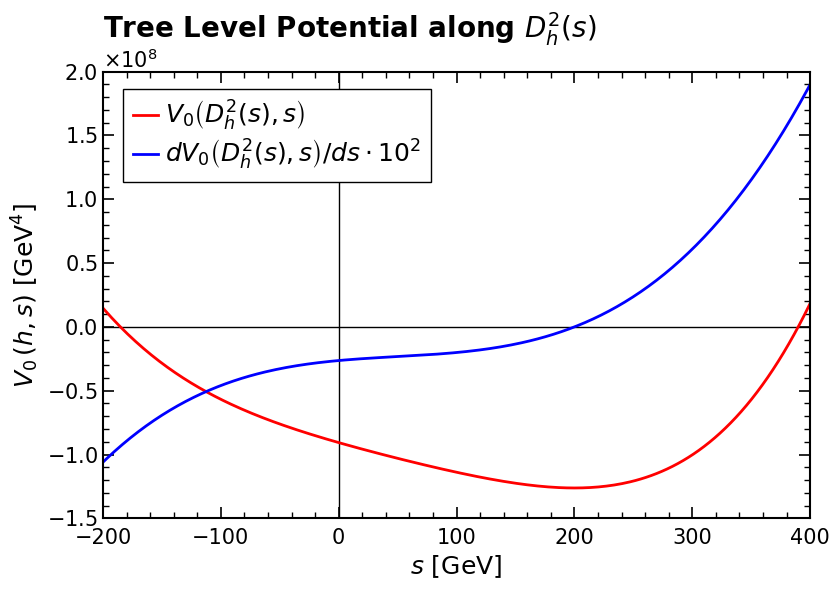

In [351]:
lH   = params["lH"]
lHS  = params["lHS"]
muHS = params["muHS"]
lS   = params["lS"]
mu3  = params["mu3"]
muH2 = params["muH2"]
muS2 = params["muS2"]

sp = (-muHS+(2*lHS*muH2+muHS**2)**0.5)/(lHS)
sm = (-muHS-(2*lHS*muH2+muHS**2)**0.5)/(lHS)

S = np.linspace(sm,sp,500)

Vs = (-(muH2**2)/(4*lH)
      + S*(muH2*muHS)/(2*lH)
      - S**2*(-12*lHS*muH2 + 12*muHS**2 + 24*lH*muS2)/(48*lH)
      - S**3*(16*lH*mu3 + 12*lHS*muHS)/(48*lH)        
      - S**4*(3*lHS**2 - 12*lH*lS)/(48*lH))

DVs = (+ (muH2*muHS)/(2*lH)
      - 2*S*(-12*lHS*muH2 + 12*muHS**2 + 24*lH*muS2)/(48*lH)
      - 3*S**2*(16*lH*mu3 + 12*lHS*muHS)/(48*lH)        
      - 4*S**3*(3*lHS**2 - 12*lH*lS)/(48*lH))

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(S, Vs, label=r'$V_{0}\left(D_h^2(s),s\right)$', color='r', lw=2, ls='-')
ax.plot(S, DVs*1e2, label=r'$dV_{0}\left(D_h^2(s),s\right)/ds \cdot 10^2$', color='b', lw=2, ls='-')

ax.set_xlim(-200, 400)
ax.set_ylim(-1.5e8, 2e8)

ax.set_xlabel(r'$s$ $\left[\mathrm{GeV}\right]$', fontsize=18)
ax.set_ylabel(r'$V_{0}\,(h,s)$ $\left[\mathrm{GeV^4}\right]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=6.7)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "upper left", bbox_to_anchor=(0.01, 0.99),
               ncol = 1, edgecolor="black", framealpha=1, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Tree Level Potential along $D_h^2(s)$", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("Figures\TL_Path.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Metastable Potential ($h=0$)

In [7]:
v0 = 246.22
u0 = 50.0
params = physical_to_lagrangian(
    m1    = 125.20,   # GeV  
    m2    = 60.0,    # GeV 
    theta = 0.01,      # rad  
    v     = v0,   # GeV
    u     = u0,     # GeV 
    lHS   = 0.25,     #     
    lS    = 0.125,      #     
)
print(params)

model = xSM(**{k: params[k] for k in ['lH','lHS','muHS','lS','mu3']},v=v0, u=u0)

{'lH': 0.1292702392878693, 'lHS': 0.25, 'muHS': -12.00961599328108, 'lS': 0.125, 'mu3': 86.09073543497686, 'muH2': 7548.935468460744, 'muS2': -3694.74495724809}


In [11]:
result = check_stability(params, v0=v0, u0=u0)

EW minimum:          v = 246.220, u = 50.000
Global minimum found: v = 0.000, u = 1000.000
SHGO optimization finished in 0.084112 seconds.
Potential is Metastable


In [23]:
lH   = params["lH"]
lHS  = params["lHS"]
muHS = params["muHS"]
lS   = params["lS"]
mu3  = params["mu3"]
muH2 = params["muH2"]
muS2 = params["muS2"]

start_time = time.perf_counter()
Radicand = mu3**2+4*lS*muS2
if Radicand >= 0:
    print("multiple minima")
    S1 = (mu3+Radicand**0.5)/(2*lS)
    S2 = (mu3-Radicand**0.5)/(2*lS)
    SignS1 = -muS2 - 2*mu3*(S1) + 3*lS*(S1)**2
    SignS2 = -muS2 - 2*mu3*(S2) + 3*lS*(S2)**2
    if SignS1 > 0:
        print(f"(0,{S1:.2f}) is a minimum")
    if SignS2 > 0:
        print(f"(0,{S2:.2f}) is a minimum")
else:
    print("Only one point in (0,0)")

end_time = time.perf_counter()
execution_time = end_time - start_time

print(f"finished in {execution_time:.6f} seconds.")

multiple minima
(0,642.74) is a minimum
finished in 0.000410 seconds.


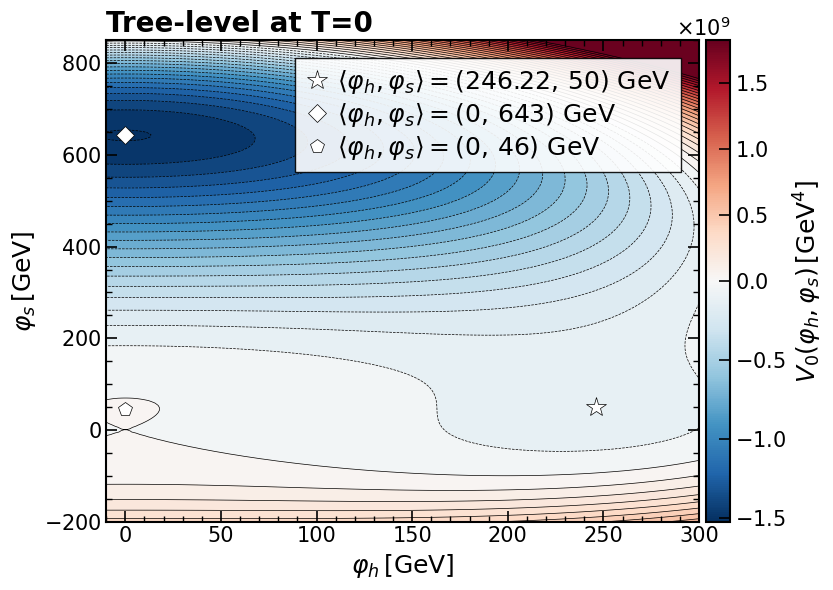

In [47]:
h_vals = np.linspace(-10, 300, 200)
s_vals = np.linspace(-200, 850, 200)
H, S   = np.meshgrid(h_vals, s_vals)
X_grid = np.column_stack([H.ravel(), S.ravel()])
V_grid = model.V0(X_grid).reshape(H.shape)
V_plot = np.clip(V_grid, np.percentile(V_grid, 0), np.percentile(V_grid, 99))
V_shifted = V_plot - model.V0(np.array([[0.0, 0.0]]))

norm = TwoSlopeNorm(vcenter=0, vmin=V_shifted.min(), vmax=V_shifted.max())
sm   = ScalarMappable(cmap='RdBu_r', norm=norm)

fig, ax = plt.subplots(figsize=(8.5, 6))

cp = ax.contourf(H, S, V_shifted, levels=50, cmap='RdBu_r', norm=norm)
ax.contour(H, S, V_shifted, levels=50, colors='k', linewidths=0.5, alpha=1)
ax.plot(v0, u0, 'w*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,label=rf'$\langle\varphi_h, \varphi_s\rangle = ({v0:.2f},\,{u0:.0f})$ GeV')
ax.plot(0, S1, 'wD', markersize=9, zorder=5, markeredgecolor='k', markeredgewidth=0.5,label=rf'$\langle\varphi_h, \varphi_s\rangle = ({0},\,{S1:.0f})$ GeV')
ax.plot(0, S2, 'wp', markersize=10, zorder=5, markeredgecolor='k', markeredgewidth=0.5,label=rf'$\langle\varphi_h, \varphi_s\rangle = ({0},\,{S2:.0f})$ GeV')

ax.set_xlabel(r'$\varphi_h \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\varphi_s \, [\mathrm{GeV}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1,   labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$V_{0}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
cbar.ax.yaxis.get_offset_text().set_fontsize(15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(-2,3))
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

ax.legend(fontsize=18, frameon=True, fancybox=False, loc = "upper right", bbox_to_anchor=(0.99, 0.99),ncol = 1, edgecolor="black", framealpha=0.9, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Tree-level at T=0", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("Figures\TL_Contour_Unstable0.pdf", format="pdf", bbox_inches="tight")
plt.show()

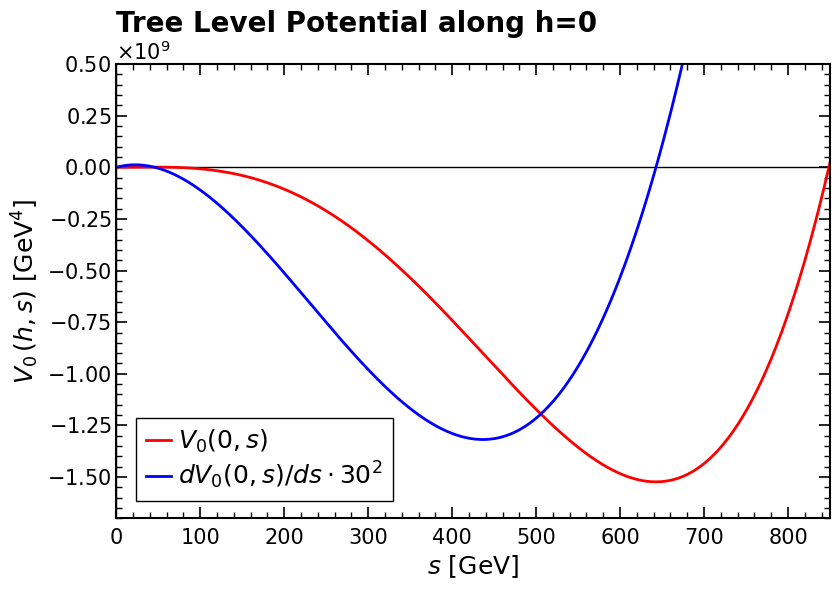

In [77]:
S = np.linspace(-50,900,500)

Vs = -0.5*muS2*S**2-mu3/3*S**3+lS/4*S**4

DVs = -muS2*S-mu3*S**2+lS*S**3

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(S, Vs, label=r'$V_{0}\left(0,s\right)$', color='r', lw=2, ls='-')
ax.plot(S, DVs*3e2, label=r'$dV_{0}\left(0,s\right)/ds \cdot 30^2$', color='b', lw=2, ls='-')

ax.set_xlim(0, 850)
ax.set_ylim(-1.7e9, 0.5e9)

ax.set_xlabel(r'$s$ $\left[\mathrm{GeV}\right]$', fontsize=18)
ax.set_ylabel(r'$V_{0}\,(h,s)$ $\left[\mathrm{GeV^4}\right]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=6.7)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower left", bbox_to_anchor=(0.01, 0.01),
               ncol = 1, edgecolor="black", framealpha=1, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Tree Level Potential along h=0", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("Figures\TL_Path_Unstable0.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Metastable Potential ($h\neq0$)

In [403]:
v0 = 246.22
u0 = 500.0
params = physical_to_lagrangian(
    m1    = 125.20,   # GeV  
    m2    = 60.0,    # GeV 
    theta = 0.01,      # rad  
    v     = v0,   # GeV
    u     = u0,     # GeV 
    lHS   = 0.05,     #     
    lS    = 0.05,      #     
)
print(params)

model = xSM(**{k: params[k] for k in ['lH','lHS','muHS','lS','mu3']},v=v0, u=u0)

result = check_stability(params, v0=v0, u0=u0)

{'lH': 0.1292702392878693, 'lHS': 0.05, 'muHS': -24.50961599328108, 'lS': 0.05, 'mu3': 45.769341129599034, 'muH2': 1832.1082714842578, 'muS2': -10354.941383349444}
EW minimum:          v = 246.220, u = 500.000
Global minimum found: v = 150.791, u = 28.313
SHGO optimization finished in 0.111115 seconds.
Potential is Metastable


In [405]:
lH   = params["lH"]
lHS  = params["lHS"]
muHS = params["muHS"]
lS   = params["lS"]
mu3  = params["mu3"]
muH2 = params["muH2"]
muS2 = params["muS2"]

Sp = (-muHS+(2*lHS*muH2+muHS**2)**0.5)/(lHS)
Sm = (-muHS-(2*lHS*muH2+muHS**2)**0.5)/(lHS)

print(Sp,Sm)

s_min = np.linspace(Sm, 600, 1000)
radicand = -s_min**2 * lHS + 2*muH2 - 2*s_min*muHS

h_plus  = np.full_like(s_min, np.nan)
h_minus = np.full_like(s_min, np.nan)

valid = radicand >= 0
h_plus[valid]  =  np.sqrt(radicand[valid]) / (np.sqrt(2) * np.sqrt(lH))
h_minus[valid] = -np.sqrt(radicand[valid]) / (np.sqrt(2) * np.sqrt(lH))

1050.168070514353 -69.78343078310978


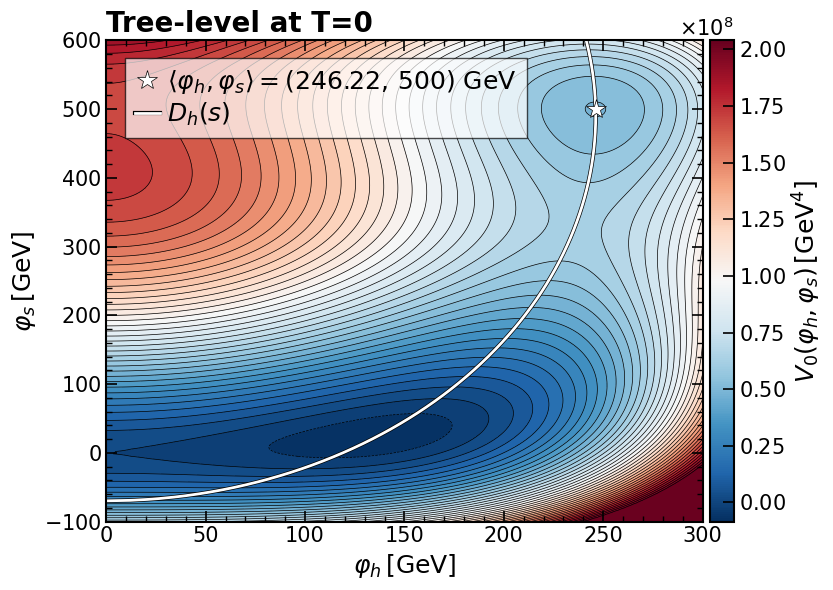

In [407]:
h_vals = np.linspace(0, 300, 200)
s_vals = np.linspace(-100, 600, 200)
H, S   = np.meshgrid(h_vals, s_vals)
X_grid = np.column_stack([H.ravel(), S.ravel()])
V_grid = model.V0(X_grid).reshape(H.shape)
V_plot = np.clip(V_grid, np.percentile(V_grid, 0), np.percentile(V_grid, 99))
V_shifted = V_plot - model.V0(np.array([[0.0, 0.0]]))

norm = Normalize(vmin=V_shifted.min(), vmax=V_shifted.max())
sm   = ScalarMappable(cmap='RdBu_r', norm=norm)

fig, ax = plt.subplots(figsize=(8.5, 6))

cp = ax.contourf(H, S, V_shifted, levels=50, cmap='RdBu_r', norm=norm)
ax.contour(H, S, V_shifted, levels=50, colors='k', linewidths=0.5, alpha=1)
ax.plot(v0, u0, 'w*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,label=rf'$\langle\varphi_h, \varphi_s\rangle = ({v0:.2f},\,{u0:.0f})$ GeV')
ax.plot(h_plus, s_min, label=r'$D_h(s)$', color='w', lw=2, ls='-', path_effects=[pe.Stroke(linewidth=3, foreground='black'), pe.Normal()])

ax.set_xlabel(r'$\varphi_h \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\varphi_s \, [\mathrm{GeV}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1,   labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$V_{0}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
cbar.ax.yaxis.get_offset_text().set_fontsize(15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(-2,3))
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

ax.legend(fontsize=18, frameon=True, fancybox=False, loc = "upper left", bbox_to_anchor=(0.01, 0.99),ncol = 1, edgecolor="black", framealpha=0.7, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Tree-level at T=0", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("Figures\TL_Contour_Unstable.pdf", format="pdf", bbox_inches="tight")
plt.show()

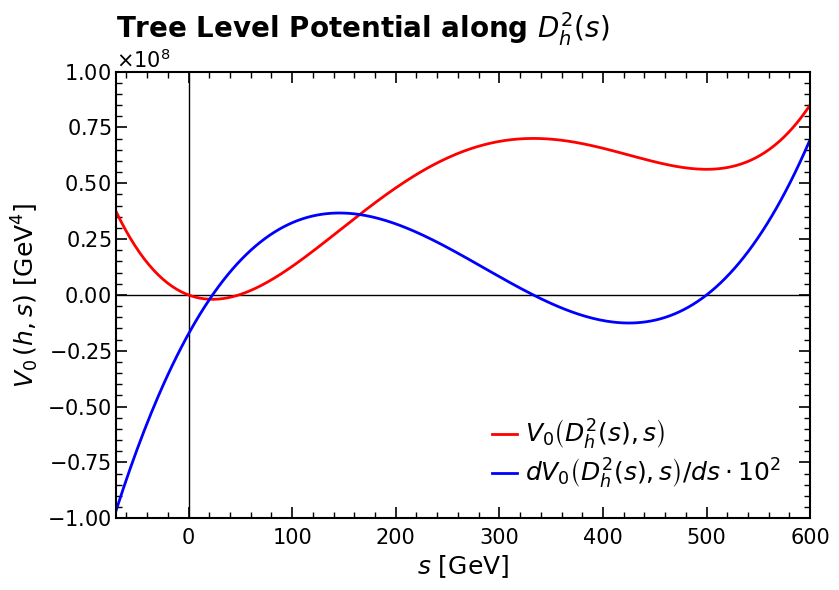

In [423]:
S = np.linspace(Sm,Sp,500)

Vs = (-(muH2**2)/(4*lH)
      + S*(muH2*muHS)/(2*lH)
      - S**2*(-12*lHS*muH2 + 12*muHS**2 + 24*lH*muS2)/(48*lH)
      - S**3*(16*lH*mu3 + 12*lHS*muHS)/(48*lH)        
      - S**4*(3*lHS**2 - 12*lH*lS)/(48*lH))

Vs0 = (-(muH2**2)/(4*lH))

DVs = (+ (muH2*muHS)/(2*lH)
      - 2*S*(-12*lHS*muH2 + 12*muHS**2 + 24*lH*muS2)/(48*lH)
      - 3*S**2*(16*lH*mu3 + 12*lHS*muHS)/(48*lH)        
      - 4*S**3*(3*lHS**2 - 12*lH*lS)/(48*lH))

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(S, Vs-Vs0, label=r'$V_{0}\left(D_h^2(s),s\right)$', color='r', lw=2, ls='-')
ax.plot(S, DVs*1e2, label=r'$dV_{0}\left(D_h^2(s),s\right)/ds \cdot 10^2$', color='b', lw=2, ls='-')

ax.set_xlim(Sm, 600)
ax.set_ylim(-1e8, 1e8)

ax.set_xlabel(r'$s$ $\left[\mathrm{GeV}\right]$', fontsize=18)
ax.set_ylabel(r'$V_{0}\,(h,s)$ $\left[\mathrm{GeV^4}\right]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=6.7)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower right", bbox_to_anchor=(0.99, 0.01),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Tree Level Potential along $D_h^2(s)$", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("Figures\TL_Path_Unstable.pdf", format="pdf", bbox_inches="tight")
plt.show()